# Import Libaries

In [112]:
import kagglehub
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
import random
import matplotlib.patches as patches

from pathlib import Path
from PIL import Image

# 0. Load Data

In [4]:
path = kagglehub.dataset_download(
    "andrewmvd/road-sign-detection",
    output_dir="data"
)

DATA_DIR = Path("data")

IMAGE_DIR = DATA_DIR / "images"
ANNOTATION_DIR = DATA_DIR / "annotations"

print(f"Images path: {IMAGE_DIR}")
print(f"Annotation path: {ANNOTATION_DIR}")

Images path: data\images
Annotation path: data\annotations


# 1. Basic Data Inspection

In [ ]:
print("="*50)
print("DATA INSPECTION")
print("="*50)

print("\nNumber of images:")
print("Images:", len(list(IMAGE_DIR.glob("*"))))
print("Annotations:", len(list(ANNOTATION_DIR.glob("*.xml"))))

image_files = [file for file in IMAGE_DIR.iterdir()]
xml_files = list(ANNOTATION_DIR.glob("*.xml"))

# Steam => file without sufix (e.g. .jpg or .xml)
image_stems = {file.stem for file in image_files}
annotation_stems = {file.stem for file in xml_files}

images_without_annotations = image_stems - annotation_stems
annotations_without_images = annotation_stems - image_stems

print("\nFile compatibility:")
print("Images without annotations:", len(images_without_annotations))
print("Annotations without images:", len(annotations_without_images))

print("\n" + "=" * 50)
print("INSPECTION COMPLETE")
print("=" * 50)

DATA INSPECTION

Number of images:
Images: 877
Annotations: 877

File compatibility
Images without annotations: 0
Annotations without images: 0

INSPECTION COMPLETE


# 2. Basic Data Inspection on Annotation Files

## 2.1 Convert .xml files into Data Frame

In [67]:
def parse_annotation(xml_file):

    tree = ET.parse(xml_file)
    root = tree.getroot()

    objects = []

    for obj in root.findall("object"):

        bbox = obj.find("bndbox")

        objects.append({
            "filename": root.find("filename").text,
            "width": int(root.find("size/width").text),
            "height": int(root.find("size/height").text),
            "class": obj.find("name").text,
            "xmin": int(bbox.find("xmin").text),
            "ymin": int(bbox.find("ymin").text),
            "xmax": int(bbox.find("xmax").text),
            "ymax": int(bbox.find("ymax").text)
        })

    return objects


records = []

for xml_file in xml_files:
    records.extend(parse_annotation(xml_file))


annotations_df = pd.DataFrame(records)

In [70]:
annotations_df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,road0.png,267,400,trafficlight,98,62,208,232
1,road1.png,400,283,trafficlight,154,63,258,281
2,road10.png,400,267,trafficlight,106,3,244,263
3,road100.png,400,385,speedlimit,35,5,363,326
4,road101.png,400,200,speedlimit,195,7,392,194


## 2.2 Data Inspection on Annotation Data Frame

In [96]:
print("="*50)
print("ANNOTATIONS DF")
print("="*50)

print("\nNumber of rows:", annotations_df.shape[0])
print("Number of columns:", annotations_df.shape[1])

print("\nColumns:")
for column, dtype in annotations_df.dtypes.items():
    print(f"- {column}: {dtype}")

print("\nMissing values:")
missing_values = annotations_df.isnull().sum()

if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("No null values")

print()
print("="*50)
print("INSPECTION COMPLETED")
print("="*50)

ANNOTATIONS DF

Number of rows: 1244
Number of columns: 8

Columns:
- filename: str
- width: int64
- height: int64
- class: str
- xmin: int64
- ymin: int64
- xmax: int64
- ymax: int64

Missing values:
No null values

INSPECTION COMPLETED


### Observation
The XML annotations were successfully parsed into a structured DataFrame containing **1,244 annotated objects** and **8 features**. No missing values were detected, indicating that the annotation data is complete and suitable for further exploratory analysis and conversion to the YOLO format.

# 3. Evaluate Data Analysis
- class distribution
- objects per image
- number of valid bounding boxes

## 3.1 Class Distribution

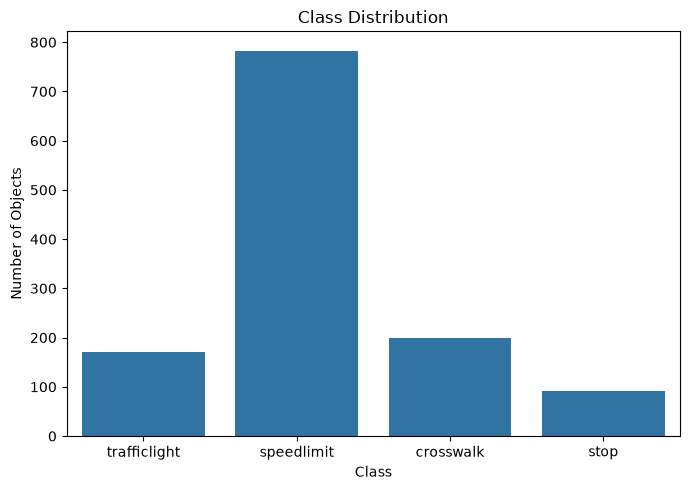

In [109]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=annotations_df,
    x="class"
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Objects")
plt.tight_layout()
plt.show()

### Observation
The classes are not evenly distributed. The `speedlimit` class contains almost **800 objects**, while `stop`, `crosswalk`, and `trafficlight` contain approximately **100–200 objects** each. This indicates a significant class imbalance in the dataset, which may affect the model's ability to detect less represented classes.

## 3.2 Objects per Image

In [110]:
objects_per_image = annotations_df.groupby("filename").size()

print(objects_per_image.describe())

count    877.000000
mean       1.418472
std        0.828585
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        8.000000
dtype: float64


### Observation
Most images contain a small number of annotated objects. The average is approximately **1.42 objects per image**, while the median is **1 object per image**, meaning that most images contain only one road sign. The maximum number of objects in a single image is **8**. This indicates that the dataset mainly consists of images with a single road sign, with only a smaller number of images containing multiple objects.

## 3.3 Number of Valid Bounding Boxes

In [111]:
invalid_boxes = annotations_df[
    (annotations_df["xmin"] < 0) |
    (annotations_df["ymin"] < 0) |
    (annotations_df["xmax"] > annotations_df["width"]) |
    (annotations_df["ymax"] > annotations_df["height"]) |
    (annotations_df["xmin"] >= annotations_df["xmax"]) |
    (annotations_df["ymin"] >= annotations_df["ymax"])
]

print("Invalid bounding boxes:", len(invalid_boxes))

Invalid bounding boxes: 0


### Info
No invalid bounding boxes were found in the dataset. All bounding box coordinates are within the corresponding image boundaries, and each bounding box has a valid width and height. This indicates that the annotations are structurally consistent and ready for further processing.

# 4. Display Image examples

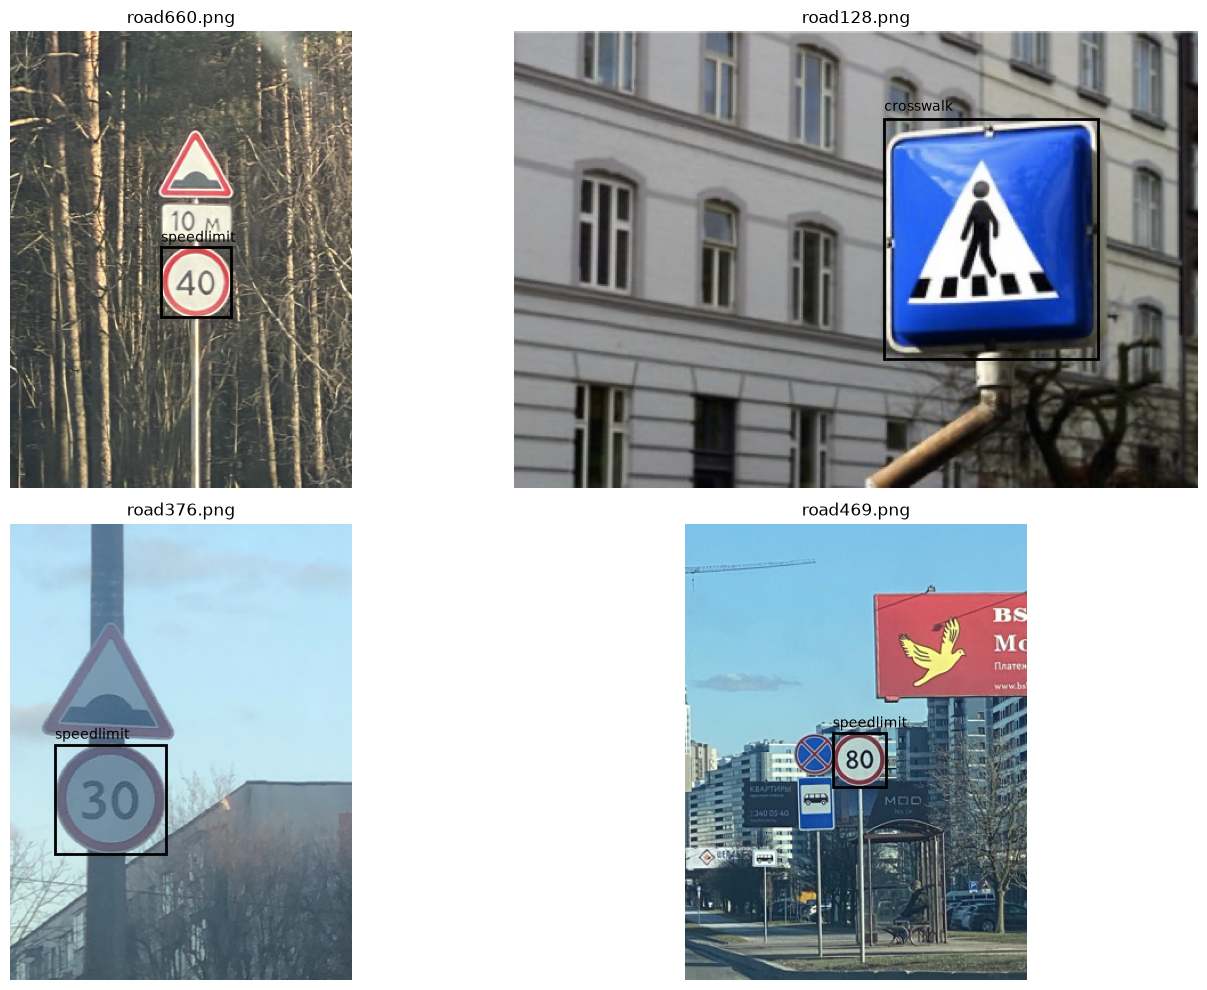

In [ ]:
# Get four unique filenames
sample_images = random.sample(
    list(annotations_df["filename"].unique()),
    4
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

# Flatten allow us to use one index [0, 1, 2, ...] not [(1, 0), (1, 2), ...]
axes = axes.flatten()

for ax, filename in zip(axes, sample_images):

    image_path = IMAGE_DIR / filename

    image = Image.open(image_path)

    ax.imshow(image)

    image_annotations = annotations_df[
        annotations_df["filename"] == filename
    ]

    for _, row in image_annotations.iterrows():

        rect = patches.Rectangle(
            (row["xmin"], row["ymin"]),
            row["xmax"] - row["xmin"],
            row["ymax"] - row["ymin"],
            linewidth=2,
            fill=False
        )

        ax.add_patch(rect)

        ax.text(
            row["xmin"],
            row["ymin"] - 5,
            row["class"],
            fontsize=10
        )

    ax.set_title(filename)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [116]:
sample_images

['road825.png',
 'road47.png',
 'road306.png',
 'road229.png',
 'road736.png',
 'road732.png']